# 03 · The Detector Zoo

Six detectors, one dataset with all three anomaly types. We highlight what each one flags, so you can see directly that **each detector is looking for something different**:

- three-sigma & IQR → global, per-feature outliers
- Mahalanobis → the multivariate, correlation-violating point
- LOF → local, low-density points
- Isolation Forest → a bit of everything
- one-class SVM → a learned boundary

We also validate the two from-scratch detectors against reference implementations.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "pyproject.toml").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.artifacts import save_figure, save_json

plt.rcParams["figure.dpi"] = 110
SEED = 7

from src.datasets.synthetic import make_dataset, ANOMALY_TYPES
from src.detectors import CANONICAL_SIX, make_detector
from src.detectors.isolation_forest import isolation_depth_scores
from src.detectors.mahalanobis import MahalanobisDetector
from src.evaluation.detection import detection_scores, recall_by_type
from scipy.stats import spearmanr
from sklearn.covariance import EmpiricalCovariance

## 1 · What each detector flags on the same data

Grey = left alone, red = flagged. The title reports each detector's recall on the **g**lobal / **l**ocal / **m**ultivariate planted anomalies.

                  precision  recall  recall_global  recall_local  \
detector                                                           
three_sigma           1.000   0.344            1.0         0.000   
iqr                   1.000   0.344            1.0         0.000   
mahalanobis           0.688   0.688            1.0         0.190   
isolation_forest      0.922   0.922            1.0         0.762   
lof                   0.969   0.969            1.0         0.952   
one_class_svm         0.703   0.703            1.0         0.429   

                  recall_multivariate  
detector                               
three_sigma                     0.000  
iqr                             0.000  
mahalanobis                     0.857  
isolation_forest                1.000  
lof                             0.952  
one_class_svm                   0.667  


PosixPath('/workspaces/outlier_arena/outputs/data/03_recall_by_type.json')

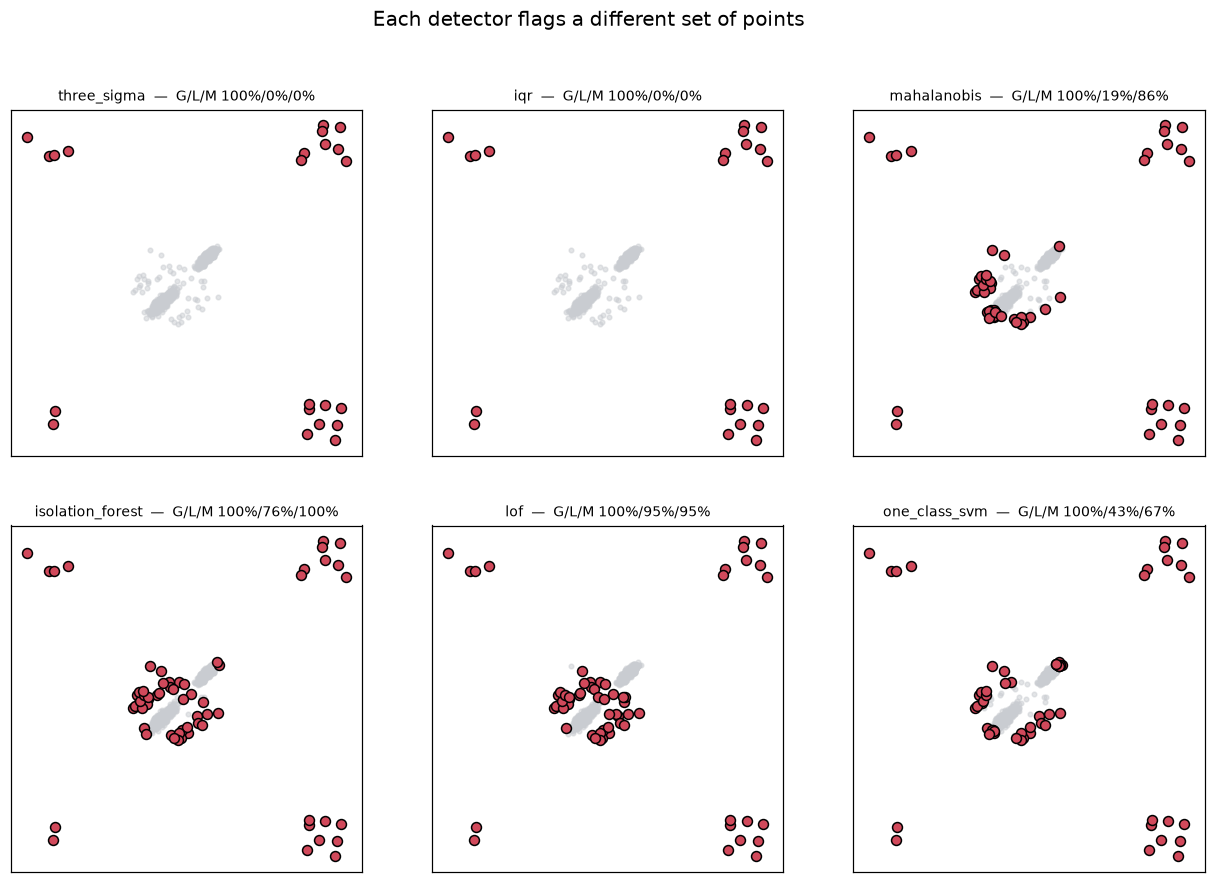

In [2]:
data = make_dataset(n_samples=800, n_features=2, contamination=0.08, seed=SEED)
X, types = data.X, data.types

labels, rows = {}, []
for m in CANONICAL_SIX:
    pred = make_detector(m, contamination=0.08).fit_predict(X)
    labels[m] = pred
    sc = detection_scores(data.y, pred)
    row = {"detector": m, "precision": sc.precision, "recall": sc.recall}
    for t in ANOMALY_TYPES:
        row[f"recall_{t}"] = recall_by_type(types, pred, t)
    rows.append(row)
recall_df = pd.DataFrame(rows).set_index("detector").round(3)
print(recall_df)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, m in zip(axes.ravel(), CANONICAL_SIX):
    pred = labels[m]
    ax.scatter(X[~pred, 0], X[~pred, 1], s=9, c="#c9ccd1", alpha=0.5)
    ax.scatter(X[pred, 0], X[pred, 1], s=42, c="#d1495b", edgecolor="k")
    r = recall_df.loc[m]
    ax.set_title(f"{m}  —  G/L/M {r.recall_global:.0%}/{r.recall_local:.0%}/{r.recall_multivariate:.0%}",
                 fontsize=9)
    ax.set(xticks=[], yticks=[])
fig.suptitle("Each detector flags a different set of points", fontsize=13)
save_figure(fig, "03_detector_zoo")
save_json(recall_df, "03_recall_by_type")

## 2 · From-scratch Isolation Forest intuition

Isolation Forest's idea: an anomaly is **isolated in few random cuts**. We implement that from scratch — average the depth at which random axis-aligned splits isolate each point — and check it ranks points the same way sklearn's optimised `IsolationForest` does.

Spearman rank correlation with sklearn: 0.923


PosixPath('/workspaces/outlier_arena/outputs/data/03_isolation_forest_scratch.json')

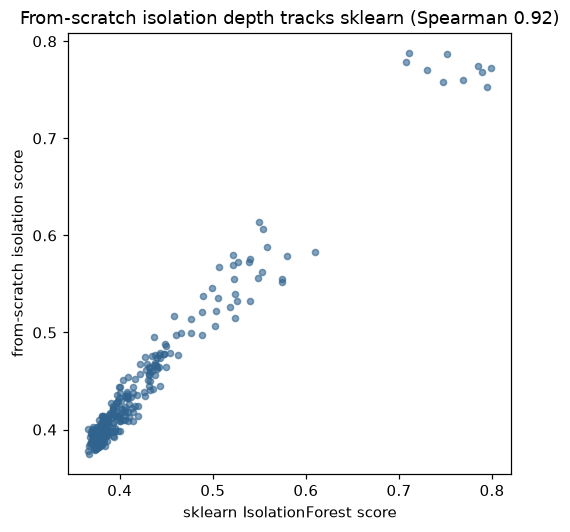

In [3]:
d3 = make_dataset(n_samples=300, contamination=0.1, seed=3)
scratch = isolation_depth_scores(d3.X, n_trees=80, subsample=128, seed=1)
sklearn_scores = make_detector("isolation_forest", contamination=0.1).score_samples(d3.X)
rho = float(spearmanr(scratch, sklearn_scores).correlation)

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(sklearn_scores, scratch, s=16, c="#30638e", alpha=0.6)
ax.set(xlabel="sklearn IsolationForest score", ylabel="from-scratch isolation score",
       title=f"From-scratch isolation depth tracks sklearn (Spearman {rho:.2f})")
save_figure(fig, "03_isolation_forest_scratch")
print(f"Spearman rank correlation with sklearn: {rho:.3f}")
save_json({"inputs": {"n_samples": 300, "n_trees": 80, "subsample": 128, "seed": 1},
           "spearman_vs_sklearn": rho}, "03_isolation_forest_scratch")

## 3 · From-scratch Mahalanobis validation

Our hand-built Mahalanobis uses the maximum-likelihood covariance, so the squared distances should be **numerically identical** to sklearn's `EmpiricalCovariance.mahalanobis`.

max absolute difference vs sklearn: 1.60e-14


PosixPath('/workspaces/outlier_arena/outputs/data/03_mahalanobis_validation.json')

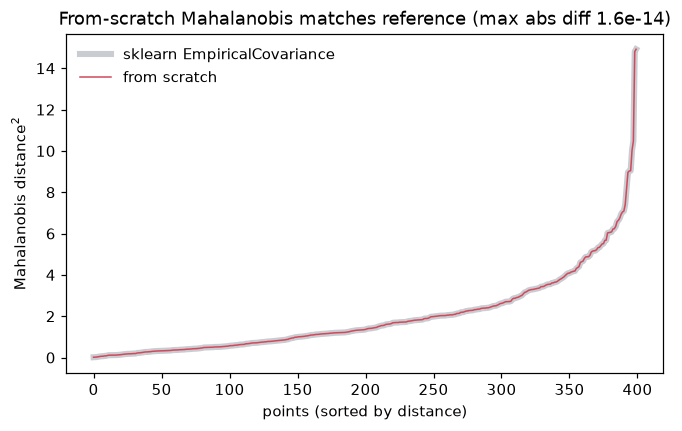

In [4]:
rng = np.random.default_rng(0)
Xm = rng.multivariate_normal([1.0, -2.0], [[3.0, 2.4], [2.4, 3.0]], size=400)
mine = MahalanobisDetector().mahalanobis_sq(Xm)
reference = EmpiricalCovariance().fit(Xm).mahalanobis(Xm)
max_abs = float(np.max(np.abs(mine - reference)))

order = np.argsort(reference)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(reference[order], lw=4, color="#c9ccd1", label="sklearn EmpiricalCovariance")
ax.plot(mine[order], lw=1, color="#d1495b", label="from scratch")
ax.set(xlabel="points (sorted by distance)", ylabel="Mahalanobis distance$^2$",
       title=f"From-scratch Mahalanobis matches reference (max abs diff {max_abs:.1e})")
ax.legend(frameon=False)
save_figure(fig, "03_mahalanobis_validation")
print(f"max absolute difference vs sklearn: {max_abs:.2e}")
save_json({"inputs": {"n_samples": 400},
           "max_abs_diff_vs_sklearn": max_abs,
           "matches_reference": bool(max_abs < 1e-6)}, "03_mahalanobis_validation")

## Takeaway

There is no detector that catches every kind of anomaly. The univariate rules see only the global points; Mahalanobis owns the multivariate one; LOF owns the local ones; Isolation Forest spreads its attention. Now that we know what each is looking for, the next notebook scores them head-to-head.

In [5]:
summary = {
    "notebook": "03_the_detector_zoo",
    "inputs": {"n_samples": 800, "contamination": 0.08, "seed": SEED},
    "recall_by_type": recall_df.to_dict(orient="index"),
    "isolation_forest_scratch_spearman": rho,
    "mahalanobis_max_abs_diff": max_abs,
    "claim": "Different detectors catch different kinds; no detector wins everywhere.",
}
save_json(summary, "03_summary")
summary

{'notebook': '03_the_detector_zoo',
 'inputs': {'n_samples': 800, 'contamination': 0.08, 'seed': 7},
 'recall_by_type': {'three_sigma': {'precision': 1.0,
   'recall': 0.344,
   'recall_global': 1.0,
   'recall_local': 0.0,
   'recall_multivariate': 0.0},
  'iqr': {'precision': 1.0,
   'recall': 0.344,
   'recall_global': 1.0,
   'recall_local': 0.0,
   'recall_multivariate': 0.0},
  'mahalanobis': {'precision': 0.688,
   'recall': 0.688,
   'recall_global': 1.0,
   'recall_local': 0.19,
   'recall_multivariate': 0.857},
  'isolation_forest': {'precision': 0.922,
   'recall': 0.922,
   'recall_global': 1.0,
   'recall_local': 0.762,
   'recall_multivariate': 1.0},
  'lof': {'precision': 0.969,
   'recall': 0.969,
   'recall_global': 1.0,
   'recall_local': 0.952,
   'recall_multivariate': 0.952},
  'one_class_svm': {'precision': 0.703,
   'recall': 0.703,
   'recall_global': 1.0,
   'recall_local': 0.429,
   'recall_multivariate': 0.667}},
 'isolation_forest_scratch_spearman': 0.922727